# Exploration and preprocessing

This notebook loads the raw satellite anomaly, SATCAT, and sunspot files, applies the existing cleaning rules, builds the TTE feature table, performs exploratory analysis, and saves `data/processed/tte.csv`.

In [1]:
from pathlib import Path
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJECT / "data" / "raw"
PROCESSED = PROJECT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
SUNSPOT_START = "1976-01-01"
MIN_TTE_OBSERVATIONS = 20
EXCLUDE_PREFIXES = ("STS-",)
ORBIT_CLASSES = ["G", "I", "C", "E", "P", "V"]
FEATURES = (["month_sin", "month_cos", "sun_27", "sun_81", "sun_trend"] +
            [f"orbit_{c}" for c in ORBIT_CLASSES] + ["prev_log_gap", "log_n_prev"])

raw = pd.read_excel(RAW / "anom5j.xls")
satcat = pd.read_csv(RAW / "satcat.csv", parse_dates=["LAUNCH_DATE", "DECAY_DATE"])
sunspot_raw = pd.read_csv(RAW / "sunspot.csv")
sunspot = pd.Series(sunspot_raw.SSN.values, index=pd.to_datetime(dict(year=sunspot_raw.Year, month=sunspot_raw.Month, day=sunspot_raw.Day)), name="ssn").sort_index()
print("Raw anomaly shape:", raw.shape)
print("SATCAT shape:", satcat.shape)
print("Sunspot shape:", sunspot.shape)


Raw anomaly shape: (5033, 21)
SATCAT shape: (70857, 17)
Sunspot shape: (6940,)


## Raw data quality

In [2]:
display(raw.head())
display(raw.dtypes.to_frame("dtype"))
display(raw.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("Raw duplicate satellite-date records:", raw.duplicated(["BIRD", "ADATE"]).sum())


,VER,EDATE,BIRD,ADATE,STIMEU,STIMEQ,DUR,STIMEL,ORBIT,NS,...,LATQ,EW,LON,LONQ,ALT,ATYPE,ADIAG,ACOMMENT,SVE,SPIN
0,5.0,1994-01-19,AFSATCOM,1990-09-11,2000,NaN,0,1632.0,G,NaN,...,NaN,E,308,NaN,35784,UNK,UNK,SFC(129) Decoder problem.,0.0,NaN
1,5.0,1994-01-19,AFTAC/WE,1992-04-15,838,NaN,0,2138.0,G,NaN,...,NaN,E,195,NaN,35784,UNK,UNK,SFC(116) Temperature sensor failure. / AP=QUIE...,0.0,NaN
2,5.0,1994-01-19,AMPTE/CCE,1987-10-27,1408,NaN,0,120.0,E,N,...,NaN,E,168,NaN,54810,UNK,UNK,SFC(118) Power supply problem.,0.0,NaN
3,5.0,1986-12-11,@PN0101,1978-10-04,1915,0.0,0,1219.0,G,N,...,0.0,W,104,0.0,35784,PC,ESD,ENCODER 2 MODE SWITCH,0.0,NaN
4,5.0,1986-12-11,@PN0102,1974-06-15,338,0.0,0,2042.0,G,N,...,0.0,W,104,0.0,35784,PC,ESD,ENCODER 2 MODE SWITCH - SENSOR TO PAM,0.0,NaN


,dtype
VER,float64
EDATE,datetime64[ns]
BIRD,object
ADATE,datetime64[ns]
STIMEU,int64
STIMEQ,float64
DUR,int64
STIMEL,float64
ORBIT,object
NS,object


,missing
SPIN,4717
NS,2034
STIMEL,1525
ACOMMENT,1393
EW,1361
LATQ,883
LONQ,883
STIMEQ,883
ORBIT,456
SVE,354


Raw duplicate satellite-date records: 1346


In [3]:
def norm_name(x):
    return re.sub(r"[^A-Z0-9]", "", str(x).upper())

def clean_anomalies(raw, start, exclude_prefixes):
    df = raw[["BIRD", "ADATE", "ORBIT", "ALT"]].copy()
    df["BIRD"] = df.BIRD.astype(str).str.strip().str.upper()
    df["ORBIT"] = df.ORBIT.astype(str).str.strip().str.upper()
    df["ADATE"] = pd.to_datetime(df.ADATE, errors="coerce")
    df["ALT"] = df.ALT.where(df.ALT > 0)
    df = df.dropna(subset=["ADATE"])
    df = df[df.ADATE >= pd.Timestamp(start)]
    return df[~df.BIRD.str.startswith(tuple(exclude_prefixes))]

def satellite_table(df):
    grouped = df.groupby("BIRD")
    satellites = pd.DataFrame({"orbit": grouped.ORBIT.agg(lambda s: s.mode().iat[0] if not s.mode().empty else "UNKNOWN"), "first_anomaly": grouped.ADATE.min()})
    for orbit in ORBIT_CLASSES:
        satellites[f"orbit_{orbit}"] = (satellites.orbit == orbit).astype(int)
    return satellites

def match_satcat(satellites, catalogue):
    payloads = catalogue[catalogue.OBJECT_TYPE == "PAY"].copy()
    payloads["key"] = payloads.OBJECT_NAME.map(norm_name)
    payloads = payloads[payloads.key.map(payloads.key.value_counts()) == 1].set_index("key")
    payloads = payloads.rename(columns=str.lower)[["launch_date", "decay_date", "inclination", "perigee", "apogee"]]
    output = satellites.copy()
    output["key"] = output.index.map(norm_name)
    output = output.join(payloads, on="key").drop(columns="key")
    matched = output.launch_date.notna() & (output.launch_date <= output.first_anomaly)
    output.loc[~matched, ["launch_date", "decay_date", "inclination", "perigee", "apogee"]] = np.nan
    output["in_satcat"] = matched
    return output

def build_tte_table(events, satellites, sunspot):
    rolling = pd.DataFrame({"sun_27": sunspot.rolling(27, min_periods=1).mean(), "sun_81": sunspot.rolling(81, min_periods=1).mean()})
    rolling["sun_trend"] = rolling.sun_27 - rolling.sun_81
    rows = []
    for satellite, group in events.groupby("BIRD"):
        dates = [pd.Timestamp(d) for d in sorted(group.ADATE.unique())]
        if satellite in {"SCATHA", "ECS 1"}:
            continue
        info = satellites.loc[satellite]
        valid_gaps = [(dates[i + 1] - dates[i]).days for i in range(len(dates) - 1) if 0 < (dates[i + 1] - dates[i]).days < 365]
        if len(valid_gaps) <= MIN_TTE_OBSERVATIONS:
            continue
        for i, start in enumerate(dates[:-1]):
            tte = (dates[i + 1] - start).days
            if not 0 < tte < 365:
                continue
            rows.append(dict(sat=satellite, start=start, tte=tte, orbit=info.orbit, in_satcat=info.in_satcat, month_sin=np.sin(2 * np.pi * start.month / 12), month_cos=np.cos(2 * np.pi * start.month / 12), **rolling.loc[start].to_dict(), prev_log_gap=np.log((start - dates[i - 1]).days) if i > 0 else np.nan, log_n_prev=np.log1p(i), **{c: info[c] for c in info.index if c.startswith("orbit_")}, age_years=(start - info.launch_date).days / 365.25 if pd.notna(info.launch_date) else np.nan, inclination=info.inclination, perigee=info.perigee, apogee=info.apogee))
    return pd.DataFrame(rows)

events = clean_anomalies(raw, SUNSPOT_START, EXCLUDE_PREFIXES)
raw_event_count = len(events)
events = events.drop_duplicates(["BIRD", "ADATE"]).reset_index(drop=True)
satellites = match_satcat(satellite_table(events), satcat)
tte = build_tte_table(events, satellites, sunspot)
if tte.empty or not np.isfinite(tte.tte).all() or (tte.tte <= 0).any():
    raise ValueError("TTE table must contain finite positive targets")
tte.to_csv(PROCESSED / "tte.csv", index=False)
print("Clean events:", len(events), "(before duplicate removal:", raw_event_count, ")")
print("TTE observations:", len(tte), "satellites:", tte.sat.nunique())
print("SATCAT matches:", int(tte.groupby("sat").in_satcat.first().sum()))


Clean events: 3447 (before duplicate removal: 4301 )
TTE observations: 2437 satellites: 37
SATCAT matches: 6


## Exploratory data analysis

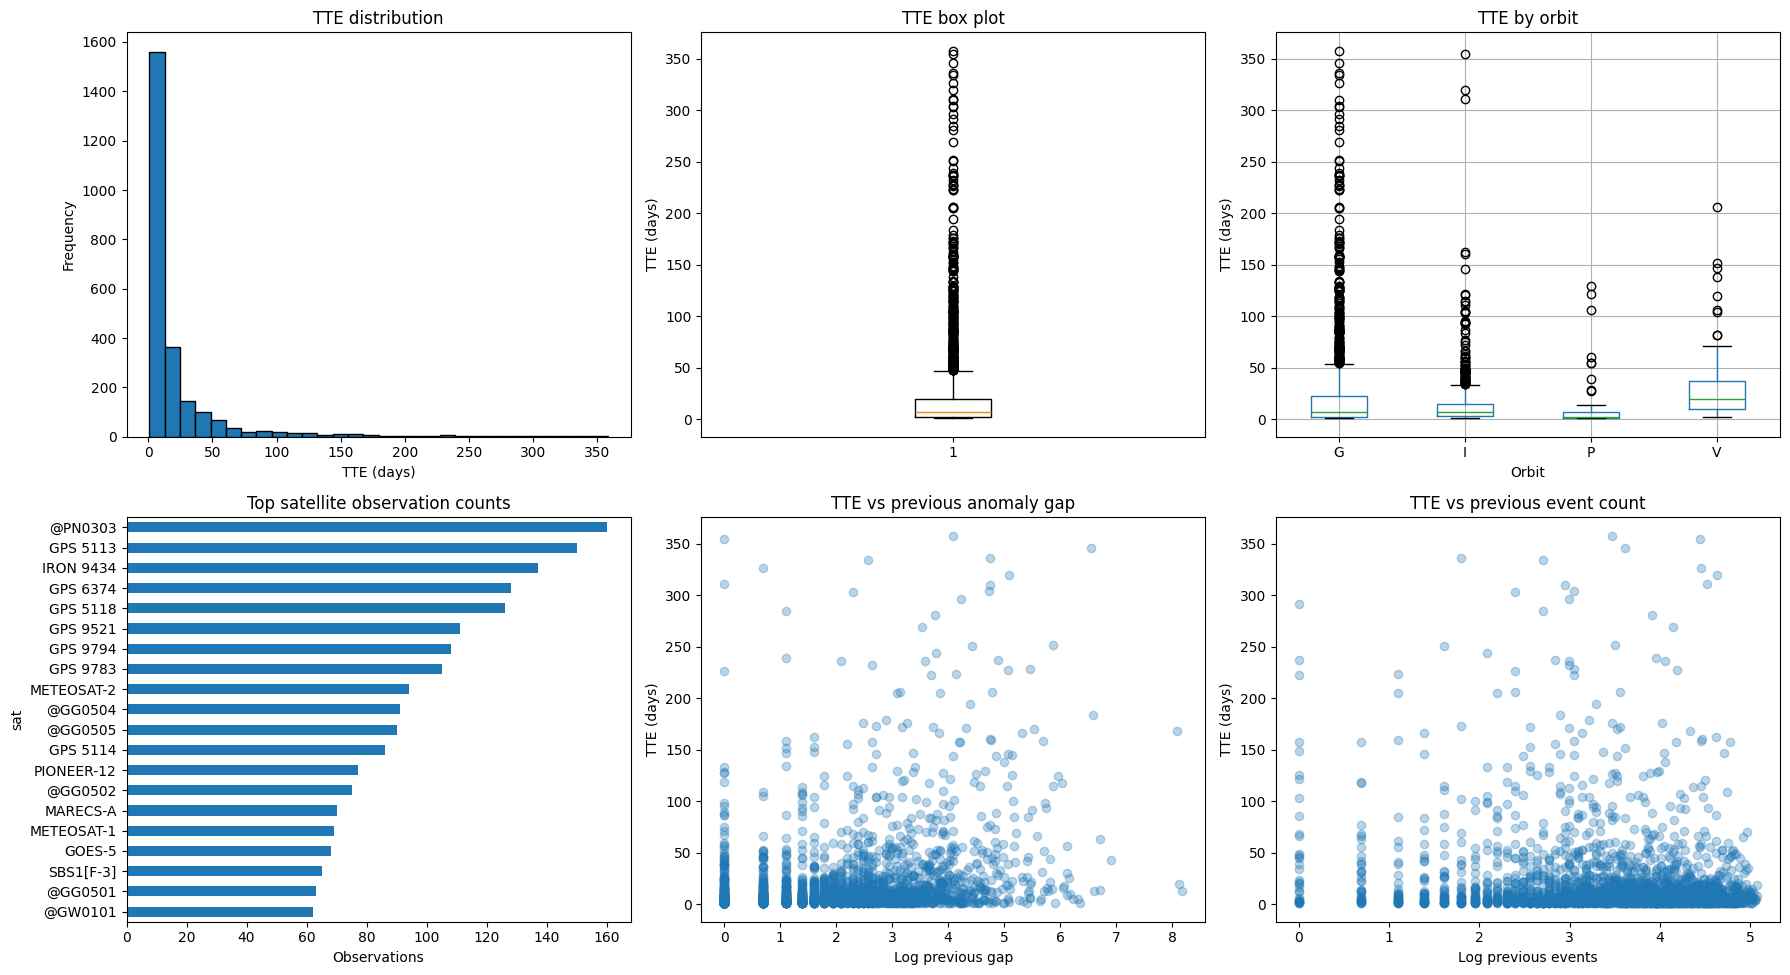

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
tte.tte.plot.hist(bins=30, edgecolor="black", ax=axes[0, 0]); axes[0, 0].set(title="TTE distribution", xlabel="TTE (days)")
axes[0, 1].boxplot(tte.tte); axes[0, 1].set(title="TTE box plot", ylabel="TTE (days)")
tte.boxplot(column="tte", by="orbit", ax=axes[0, 2]); axes[0, 2].set(title="TTE by orbit", xlabel="Orbit", ylabel="TTE (days)")
tte.sat.value_counts().head(20).sort_values().plot.barh(ax=axes[1, 0]); axes[1, 0].set(title="Top satellite observation counts", xlabel="Observations")
axes[1, 1].scatter(tte.prev_log_gap, tte.tte, alpha=.3); axes[1, 1].set(title="TTE vs previous anomaly gap", xlabel="Log previous gap", ylabel="TTE (days)")
axes[1, 2].scatter(tte.log_n_prev, tte.tte, alpha=.3); axes[1, 2].set(title="TTE vs previous event count", xlabel="Log previous events", ylabel="TTE (days)")
plt.suptitle(""); plt.tight_layout(); plt.show()


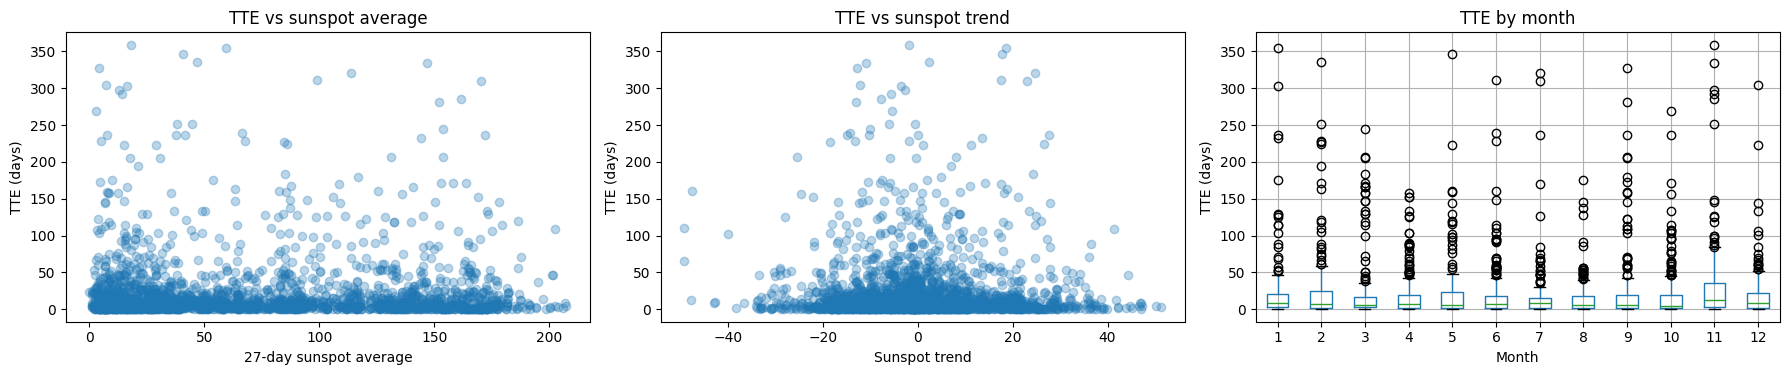

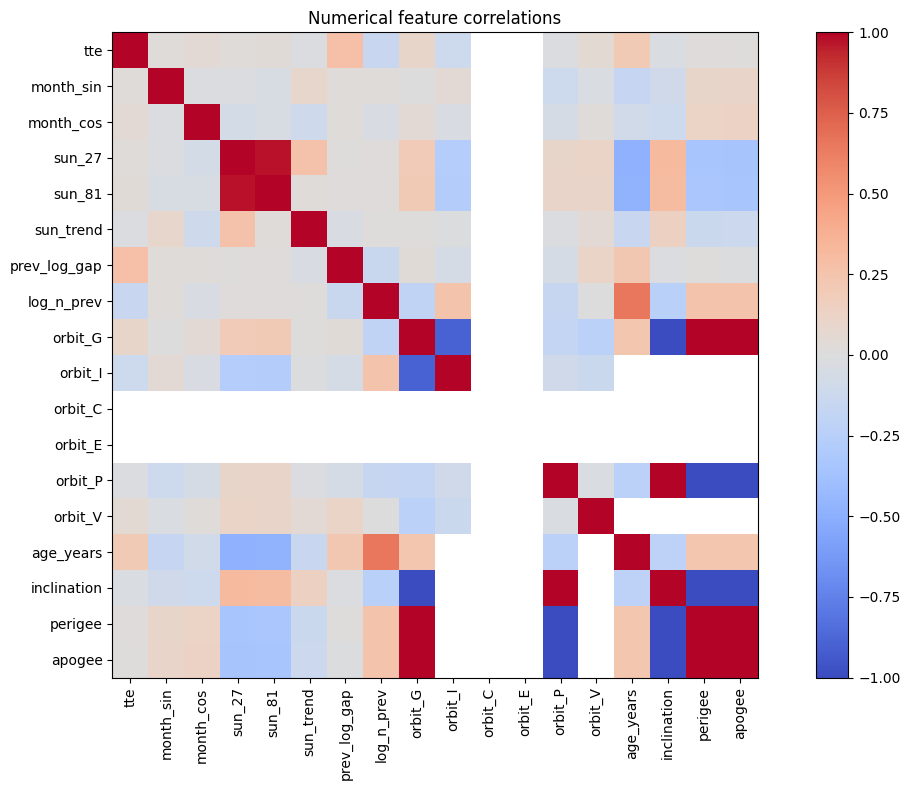

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].scatter(tte.sun_27, tte.tte, alpha=.3); axes[0].set(title="TTE vs sunspot average", xlabel="27-day sunspot average", ylabel="TTE (days)")
axes[1].scatter(tte.sun_trend, tte.tte, alpha=.3); axes[1].set(title="TTE vs sunspot trend", xlabel="Sunspot trend", ylabel="TTE (days)")
tte.assign(month=pd.to_datetime(tte.start).dt.month).boxplot(column="tte", by="month", ax=axes[2]); axes[2].set(title="TTE by month", xlabel="Month", ylabel="TTE (days)")
plt.suptitle(""); plt.tight_layout(); plt.show()
correlations = tte.select_dtypes(include="number").corr()
fig, ax = plt.subplots(figsize=(12, 8)); image = ax.imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1); ax.set_xticks(range(len(correlations.columns)), correlations.columns, rotation=90); ax.set_yticks(range(len(correlations.columns)), correlations.columns); fig.colorbar(image, ax=ax); ax.set_title("Numerical feature correlations"); fig.tight_layout(); plt.show()


In [6]:
display(tte.tte.describe(percentiles=[.25, .5, .75]).to_frame("TTE days"))
display(tte.groupby("sat").size().describe().to_frame("observations per satellite"))
display(tte.groupby("orbit").size().to_frame("observations"))
display(pd.DataFrame({"missing": tte.isna().sum(), "dtype": tte.dtypes.astype(str)}))
print("Saved:", PROCESSED / "tte.csv")


,TTE days
count,2437.000000
mean,21.474354
std,41.687573
min,1.000000
25%,2.000000
50%,7.000000
75%,20.000000
max,358.000000


,observations per satellite
count,37.000000
mean,65.864865
std,41.188026
min,21.000000
25%,26.000000
50%,63.000000
75%,91.000000
max,160.000000


,observations
orbit,
G,1498
I,814
P,48
V,77


,missing,dtype
sat,0,object
start,0,datetime64[ns]
tte,0,int64
orbit,0,object
in_satcat,0,bool
month_sin,0,float64
month_cos,0,float64
sun_27,0,float64
sun_81,0,float64
sun_trend,0,float64


Saved: C:\Users\sowmy\OneDrive\Sowmya\College\SEM-5\ML\Satellite-Anomaly-Prediction-ML-Project\data\processed\tte.csv
